In [23]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt

In [24]:
# pulizia per sicurezza

#os.system("rm *.h5")
os.system("rm summary.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

0

In [25]:
# VARIABILI DA PAPERMILL (verranno sovrascritte)
pressione_atm = 1.0
moltiplicatore = 1.0
perc_water = 0.15
arricch_max = 13.469  # in percentuale
arricch_min = 1.0     # in percentuale
t_water = 350.0
t_fuel = 600.0


VARIABILI IMPORTANTI

In [26]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters("../parametri.txt")

# --- Parametri Geometrici e Logici ---
R_CORE    = p['R_CORE']*moltiplicatore
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']
R_PIPE    = p['R_PIPE']

# --- Parametri Target e Sorgente ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']
S         = p['S']
bin_ris   = p['bin_ris']
batches   = p['batches_fix']
particles = p['particles_fix']

# --- Parametri Pin/Lattice Base ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']

enrich_target = p['enrich_target']

# ==========================================
# SOVRASCRITTURA CON PARAMETRI DI PAPERMILL
# ==========================================
Pressione_funzionamento = pressione_atm * 101325  # atm in Pa
PITCH     = p['PITCH'] * moltiplicatore
mix       = perc_water
T_water   = t_water
T_resto   = t_fuel

# I valori dal txt sono in percentuale, convertiamoli in frazione
enrich_max = arricch_max / 100.0
enrich_min = arricch_min / 100.0


In [27]:
from CoolProp.CoolProp import PropsSI

def densita_mix_dinamica(T_K, P_Pa= Pressione_funzionamento, frac_mass_H2O=mix):
    # Calcolo in kg/m^3 e conversione in g/cm^3
    rho_H2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'Water') / 1000     # D sta per densità
    rho_D2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'HeavyWater') / 1000
    
    # Calcolo miscela assumendo volumi ideali additivi
    rho_mix = 1 / (frac_mass_H2O / rho_H2O + (1 - frac_mass_H2O) / rho_D2O) # Formula di additività dei volumi specifici
    return rho_mix

print(f"Densità del mix a {T_water} K e {Pressione_funzionamento/1e6} MPa: {densita_mix_dinamica(T_water, Pressione_funzionamento, mix):.4f} g/cm^3")

Densità del mix a 350.0 K e 0.101325 MPa: 1.0629 g/cm^3


MATERIALI

In [28]:
# materiale di rivestimento
cladding = openmc.Material(name='cladding')
cladding.temperature = T_resto
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material(name='water')
water.temperature = T_water
water.add_nuclide('H1', mix)
water.add_nuclide('H2', 1-mix)
water.add_element('O', 1.0)
water.set_density('g/cm3', densita_mix_dinamica(T_water)) # Usa la densità corretta
water.add_s_alpha_beta('c_D_in_D2O') 
water.add_s_alpha_beta('c_H_in_H2O') 

# aggiungo un riflettore 
reflector = openmc.Material(name='reflector')
reflector.temperature = T_resto
reflector.add_element('C', 1.0)
reflector.set_density('g/cm3', 1.75) 

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.temperature = T_resto
marker_mat.set_density('g/cm3', 1e-10) 
marker_mat.add_nuclide('He4', 1.0) 

void_air = openmc.Material(name='void_air')
void_air.temperature = T_resto
void_air.set_density('g/cm3', 1e-10) 
void_air.add_nuclide('N14', 1)

mat_target = openmc.Material(name='mat_target')
mat_target.temperature = T_resto
mat_target.add_nuclide('U235', enrich_target)
mat_target.add_nuclide('U238', 1.0 - enrich_target)
mat_target.add_nuclide('O16', 2.0)
mat_target.set_density('g/cm3', 10.96)

GEOMETRIA

In [29]:
# --- 0. SUPERFICI DEL MONDO E SORGENTE ---
# Definiamo un "mondo" confinato dal vuoto assoluto per non avere riflessioni
world_cyl = openmc.ZCylinder(r=R_TARGET + 10.0, boundary_type='vacuum')
world_bot = openmc.ZPlane(z0=-10.0, boundary_type='vacuum')
world_top = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Superficie Sorgente (come marker visivo)
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2.0, r=0.5)

# --- 1. SUPERFICI DEL TARGET ---
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))
cyl_target = openmc.ZCylinder(r=R_TARGET)

# --- 2. DEFINIZIONE REGIONI E CELLE ---

# A. Target Solido
region_target_solid = -cyl_target & +z_tgt_bot & -z_tgt_top
c_target = openmc.Cell(name='target', fill=mat_target, region=region_target_solid)

# B. Marker Sorgente
region_source_marker = -sphere_src
c_source_marker = openmc.Cell(name='source_marker', fill=marker_mat, region=region_source_marker)

# C. Superficie di Controllo (Vuoto circostante per l'estrazione dei Tally)
# È tutto lo spazio dentro il boundary del mondo, escluso il target e la sorgente
region_world = -world_cyl & +world_bot & -world_top
region_void_gap = region_world & ~region_target_solid & ~region_source_marker

c_void_gap = openmc.Cell(name='void_gap', fill=void_air, region=region_void_gap)

# --- 3. ESPORTAZIONE ---

# Esportazione Materiali (solo i necessari)
materials = openmc.Materials([mat_target, void_air, marker_mat])
materials.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml"
materials.export_to_xml()

# Esportazione Geometria
all_cells = [c_target, c_source_marker, c_void_gap]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()

print("Geometria generata: Modello Target-Only per estrazione spettro fotoneutronico.")

Geometria generata: Modello Target-Only per estrazione spettro fotoneutronico.


PLOTTING

/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(



VISUALIZZAZIONE GEOMETRIA

1. VISTA DALL'ALTO (Piano XY nel Core)


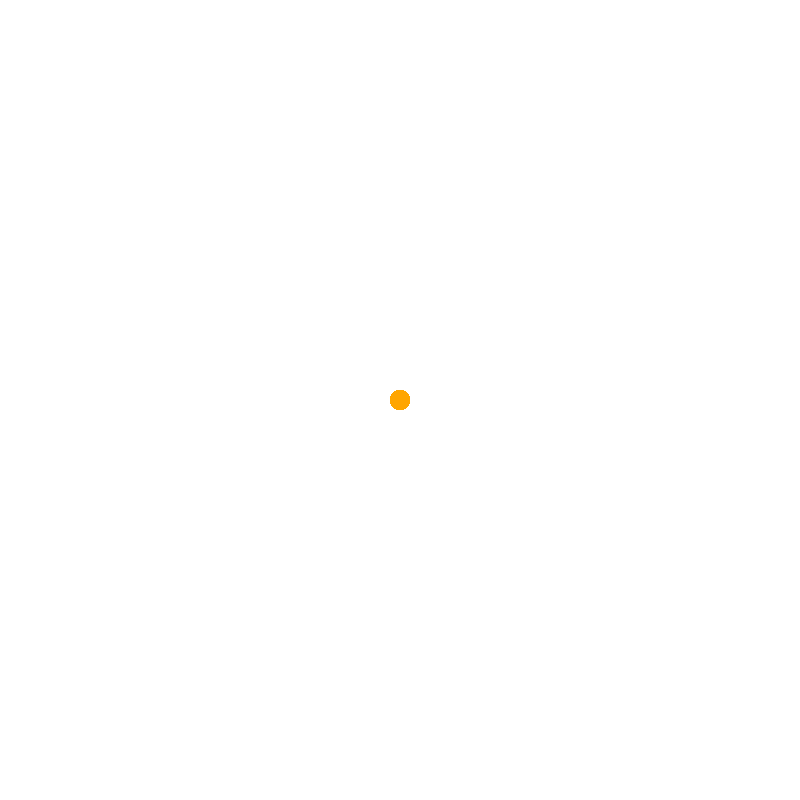

2. VISTA LATERALE (Piano XZ)


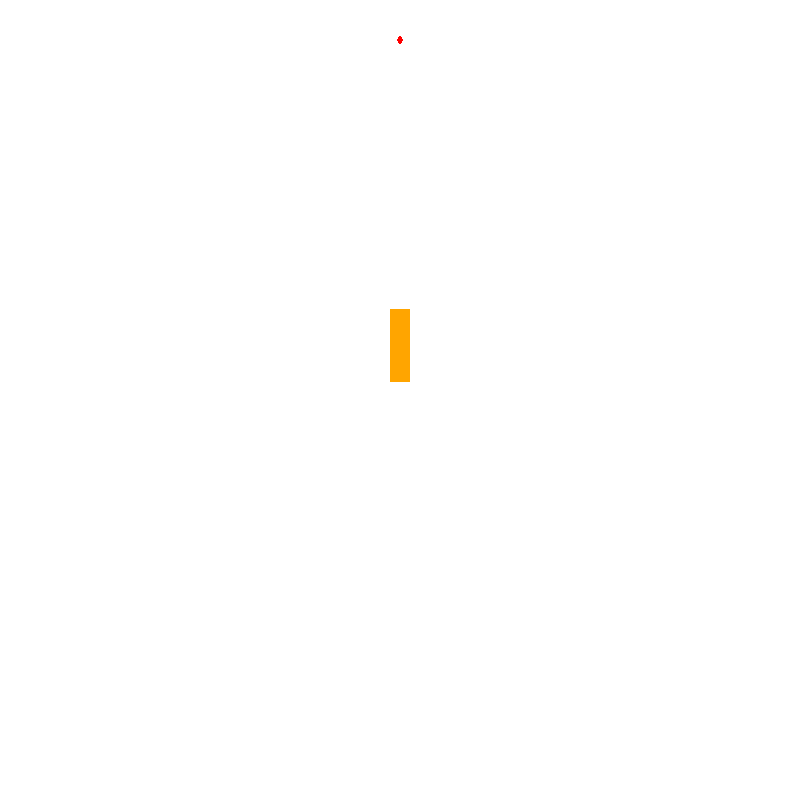

In [30]:
color_map = {
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red' ,     # Marker sorgente
    void_air: 'white',      # Vuoto (aria)
    mat_target: 'orange'   # Target
}

cmap = plt.get_cmap('YlOrBr')

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

SETTINGS FIXED

In [31]:
# Lettura dello spettro in energia
data = np.loadtxt("synchrotron_1_37_MeV.txt")
energy_midpoints, pdf_array = data[:,0], data[:,1]
energy_dist = openmc.stats.Tabular(energy_midpoints, pdf_array, interpolation='linear-linear')

# Definizione della sorgente
source = openmc.IndependentSource()
source.space = openmc.stats.Point((0, 0, H_CORE + 2.0))
source.angle = openmc.stats.Monodirectional((0, 0, -1))
source.energy = energy_dist
source.particle = 'photon'

# Impostazioni di simulazione
settings = openmc.Settings()

# Gestione particelle perse (alza il limite se la geometria è complessa ma corretta)
settings.max_lost_particles = 50

settings.batches = batches
settings.particles = particles
settings.run_mode = 'fixed source'

settings.cutoff = {'weight': 1.0e-5, 'energy_photon': 1.0e6} # cutoff a 1 MeV per i fotoni, così non simulo fotoni che non mi interessano
settings.temperature = {'method': 'interpolation'}

settings.max_collisions = 10000

settings.source = source

settings.photon_transport = True
settings.photonuclear_physics = True
settings.create_fission_neutrons = True

settings.export_to_xml()

# METTI TRACKING DEI NEUTRONI

TALLIES

In [32]:
import glob

tallies = openmc.Tallies()

# Filtro sulla cella vuota attorno al target per campionare ciò che esce
cell_filter = openmc.CellFilter([c_void_gap])
particle_filter = openmc.ParticleFilter(['neutron'])

# Filtro Energetico (da 1 meV a 20 MeV in 500 bin logaritmici)
energy_bins = np.logspace(2, 8, 500)
energy_filter = openmc.EnergyFilter(energy_bins)

import openmc
import numpy as np

# Filtro sulle superfici esterne del target
surface_filter = openmc.SurfaceFilter([cyl_target, z_tgt_bot, z_tgt_top])
particle_filter = openmc.ParticleFilter(['neutron'])

# Filtro Angolare Polare (da 0 a Pi in 180 bin)
polar_bins = np.linspace(0, np.pi, 180)
polar_filter = openmc.PolarFilter(polar_bins)

# Creazione del Tally
tally_polar_true = openmc.Tally(name='spettro_angolare_vero')
tally_polar_true.filters = [surface_filter, particle_filter, polar_filter]

# Fondamentale: usare 'current' per contare gli attraversamenti esatti
tally_polar_true.scores = ['current'] 
tallies.append(tally_polar_true)

# Tally Spettro Energetico
tally_energy = openmc.Tally(name='spettro_energia_neutroni')
tally_energy.filters = [cell_filter, particle_filter, energy_filter]
tally_energy.scores = ['flux']
tallies.append(tally_energy)

tallies.export_to_xml()


In [33]:
import os
import glob
import shutil

percorso_eseguibile = "/home/bossi_ricky/miniconda3/envs/openmc-env/bin/openmc"
openmc.run(output=True, geometry_debug=False, threads=40)

# Rinomina l'ultimo statepoint generato
sp_files = glob.glob('statepoint.*.h5')

if sp_files:
    latest_sp = max(sp_files, key=os.path.getctime)
    new_sp_name = f"statepoint_{batches}.h5"
    shutil.move(latest_sp, new_sp_name)
    print(f"File statepoint salvato con successo: {new_sp_name}")
else:
    # Questo solleva un errore se OpenMC non ha prodotto il file, bloccando run_pot.py
    raise FileNotFoundError("ERRORE CRITICO: OpenMC NON ha generato alcun file statepoint! Controlla i settings.")

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################